# Credit Card Default Prediction
### End-to-End Machine Learning Pipeline

**Objective:** Predict whether a credit card customer will default on payment next month.

---

**Notebook Flow:**
1. Import Libraries
2. Load & Explore Data
3. Data Cleaning & Type Casting
4. Exploratory Data Analysis (EDA)
5. Feature Engineering
6. Outlier Detection
7. Skewness Analysis
8. Train-Test Split
9. Preprocessing Pipelines
10. Baseline Models (No Imbalance Handling)
11. Imbalance Handling — SMOTE & Class Weights
12. Hyperparameter Tuning
13. Final Comparison Table
14. Save Best Model

---
## Step 1: Import Libraries

In [3]:
# ── Core libraries ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ────────────────────────────────────────────────────────
import seaborn as sns
import matplotlib.pyplot as plt

# ── Preprocessing & Pipelines ────────────────────────────────────────────
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    PowerTransformer,
    FunctionTransformer
)

# ── Models ───────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# ── Imbalance Handling ───────────────────────────────────────────────────
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# ── Model Selection & Evaluation ─────────────────────────────────────────
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score
)

# ── Model Saving ─────────────────────────────────────────────────────────
import pickle

print("All libraries imported successfully!")

All libraries imported successfully!


---
## Step 2: Load & Explore Data

In [4]:
# Load dataset
df = pd.read_csv("Credit_Card_Default.csv")

print(f"Dataset Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Dataset Shape: (30000, 25)
Rows: 30000, Columns: 25


In [5]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [6]:
# Check for duplicate rows
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


In [7]:
# First 5 rows preview
df.head(5)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [8]:
# Statistical summary of all columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


---
## Step 3: Data Cleaning & Type Casting

In [9]:
# Rename columns for better readability
# 'default.payment.next.month' → 'DEFAULT'  |  'SEX' → 'GENDER'
df.rename(columns={
    'default.payment.next.month': 'DEFAULT',
    'SEX': 'GENDER'
}, inplace=True)

# Drop identifier column (not useful for modeling)
df.drop(columns=['ID'], inplace=True)

print("Renamed and dropped columns.")
print(f"New shape: {df.shape}")

Renamed and dropped columns.
New shape: (30000, 24)


In [10]:
# Check missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")

Missing values per column:
No missing values found.


In [11]:
# Fix EDUCATION column:
# Original encoding: 1=Graduate School, 2=University, 3=High School, 4=Others, 5=Unknown, 6=Unknown
# Merge 0, 5, 6 into category 4 (Others/Unknown) since they have no clear meaning
df["EDUCATION"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
print("EDUCATION value counts after cleaning:")
print(df["EDUCATION"].value_counts().sort_index())

EDUCATION value counts after cleaning:
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64


In [12]:
# Cast categorical columns to proper data types
df["GENDER"]    = df["GENDER"].astype("category")
df["EDUCATION"] = df["EDUCATION"].astype("category")
df["MARRIAGE"]  = df["MARRIAGE"].astype("category")
df["DEFAULT"]   = df["DEFAULT"].astype("bool")

print("Updated data types:")
print(df.dtypes)

Updated data types:
LIMIT_BAL     float64
GENDER       category
EDUCATION    category
MARRIAGE     category
AGE             int64
PAY_0           int64
PAY_2           int64
PAY_3           int64
PAY_4           int64
PAY_5           int64
PAY_6           int64
BILL_AMT1     float64
BILL_AMT2     float64
BILL_AMT3     float64
BILL_AMT4     float64
BILL_AMT5     float64
BILL_AMT6     float64
PAY_AMT1      float64
PAY_AMT2      float64
PAY_AMT3      float64
PAY_AMT4      float64
PAY_AMT5      float64
PAY_AMT6      float64
DEFAULT          bool
dtype: object


In [13]:
# Target class distribution — check for imbalance
target_dist = df['DEFAULT'].value_counts(normalize=True)
print("Target Distribution (proportion):")
print(target_dist)
print(f"\nClass ratio — No Default: {target_dist[False]:.1%}  |  Default: {target_dist[True]:.1%}")
print("\n⚠️  Dataset is IMBALANCED — will handle with SMOTE and class weights.")

Target Distribution (proportion):
DEFAULT
False    0.7788
True     0.2212
Name: proportion, dtype: float64

Class ratio — No Default: 77.9%  |  Default: 22.1%

⚠️  Dataset is IMBALANCED — will handle with SMOTE and class weights.


---
## Step 4: Exploratory Data Analysis (EDA)

In [14]:
# Separate numeric and categorical columns for analysis
df_cat = df.select_dtypes(include=["object", "category"])
df_num = df.select_dtypes(include=['int64', 'float64'])

print(f"Numeric columns  : {list(df_num.columns)}")
print(f"Categorical cols : {list(df_cat.columns)}")

Numeric columns  : ['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
Categorical cols : ['GENDER', 'EDUCATION', 'MARRIAGE']


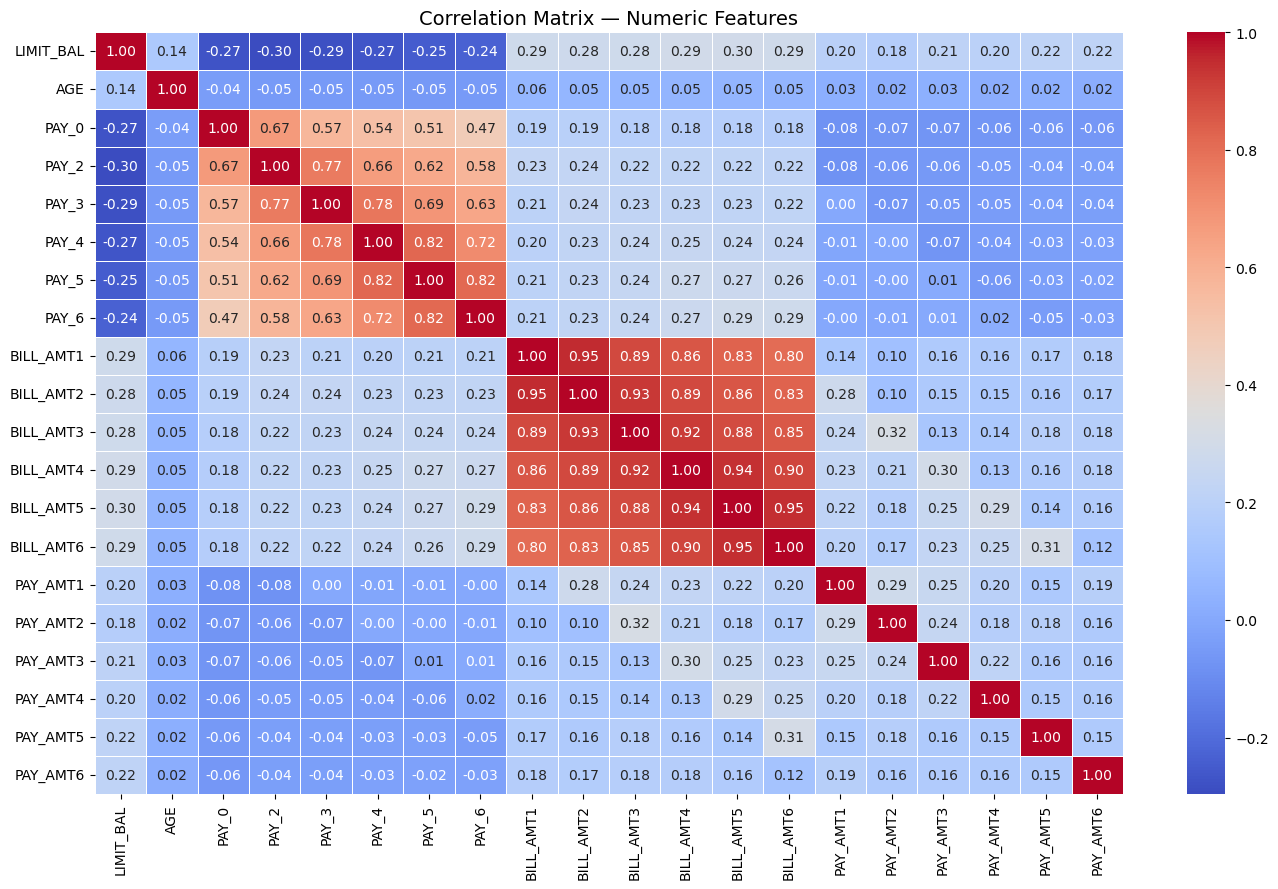

In [15]:
# Correlation heatmap — shows linear relationships among numeric features
# Helps detect multicollinearity (highly correlated features that may be redundant)
plt.figure(figsize=(14, 9))
sns.heatmap(
    df_num.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Matrix — Numeric Features", fontsize=14)
plt.tight_layout()
plt.show()

---
## Step 5: Feature Engineering

Creating new meaningful features from existing ones to improve model performance.

In [16]:
# UTIL_RATE: Credit utilization ratio — how much of the credit limit is used
# Clipped to [-1, 2] to handle rare negative bills; NaN (limit=0) → 0
df['UTIL_RATE'] = (
    df['BILL_AMT1'] / df['LIMIT_BAL'].replace(0, np.nan)
).clip(-1, 2).fillna(0)

# AVG_PAY_STATUS: Average payment status over the last 6 months
# Higher values mean more delayed payments
df['AVG_PAY_STATUS'] = df[['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']].mean(axis=1)

# TOTAL_BILL: Total bill amount across 6 months
df['TOTAL_BILL'] = df[['BILL_AMT1','BILL_AMT2','BILL_AMT3',
                        'BILL_AMT4','BILL_AMT5','BILL_AMT6']].sum(axis=1)

# TOTAL_PAY: Total payment made across 6 months
df['TOTAL_PAY'] = df[['PAY_AMT1','PAY_AMT2','PAY_AMT3',
                       'PAY_AMT4','PAY_AMT5','PAY_AMT6']].sum(axis=1)

# PAY_RATIO: Ratio of total payment to total bill
# High ratio = good payer; Low ratio = possible defaulter
# Clipped to [-2, 5] to handle edge cases; NaN (total_bill=0) → 0
df['PAY_RATIO'] = (
    df['TOTAL_PAY'] / df['TOTAL_BILL'].replace(0, np.nan)
).clip(-2, 5).fillna(0)

print("Engineered features added:")
print(" - UTIL_RATE      : Credit utilization ratio")
print(" - AVG_PAY_STATUS : Average payment delay status")
print(" - TOTAL_BILL     : Sum of 6-month bills")
print(" - TOTAL_PAY      : Sum of 6-month payments")
print(" - PAY_RATIO      : Payment-to-bill ratio")
print(f"\nUpdated shape: {df.shape}")

Engineered features added:
 - UTIL_RATE      : Credit utilization ratio
 - AVG_PAY_STATUS : Average payment delay status
 - TOTAL_BILL     : Sum of 6-month bills
 - TOTAL_PAY      : Sum of 6-month payments
 - PAY_RATIO      : Payment-to-bill ratio

Updated shape: (30000, 29)


---
## Step 6: Outlier Detection

In [17]:
# Refresh numeric columns (includes engineered features, excludes target)
df_num = df.select_dtypes(include=['int64', 'float64'])
df_num = df_num.drop(columns=['DEFAULT'], errors='ignore')

# Detect outliers using IQR method
# A data point is an outlier if it falls below Q1 - 1.5*IQR or above Q3 + 1.5*IQR
def detect_outliers(col):
    Q1 = col.quantile(0.25)
    Q3 = col.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((col < lower) | (col > upper)).sum()

outlier_counts = {col: detect_outliers(df_num[col]) for col in df_num.columns}
outliers_df = pd.DataFrame(
    list(outlier_counts.items()),
    columns=["Feature", "Outlier_Count"]
).sort_values("Outlier_Count", ascending=False)

print("Outlier counts per feature (IQR method):")
print(outliers_df.to_string(index=False))

Outlier counts per feature (IQR method):
       Feature  Outlier_Count
         PAY_2           4410
         PAY_3           4209
         PAY_4           3508
         PAY_0           3130
         PAY_6           3079
      PAY_AMT4           2994
         PAY_5           2968
      PAY_AMT6           2958
      PAY_AMT5           2945
     TOTAL_PAY           2898
      PAY_AMT1           2745
     BILL_AMT5           2725
      PAY_AMT2           2714
     BILL_AMT6           2693
     BILL_AMT4           2622
      PAY_AMT3           2598
    TOTAL_BILL           2575
     BILL_AMT3           2469
     BILL_AMT1           2400
     BILL_AMT2           2395
AVG_PAY_STATUS           2290
     PAY_RATIO            998
           AGE            272
     LIMIT_BAL            167
     UTIL_RATE              0


**Note on Outlier Treatment:**  
Outliers in financial data (PAY_AMT, BILL_AMT) are **expected** — they represent legitimate high-value transactions.  
Instead of hard capping, we handle them in the preprocessing pipeline:  
- PAY_AMT columns → `log1p` transformation (compresses extreme values)
- BILL_AMT columns → Yeo-Johnson `PowerTransformer` (handles both skew and outliers)

---
## Step 7: Skewness Analysis

In [18]:
# Calculate skewness for all numeric features
# Skewness > 1 or < -1 indicates significant skewness
skewness = df_num.skew().sort_values(ascending=False)
print("Skewness values (sorted):")
print(skewness)

Skewness values (sorted):
PAY_AMT2          30.453817
PAY_AMT3          17.216635
PAY_AMT1          14.668364
TOTAL_PAY         14.616877
PAY_AMT4          12.904985
PAY_AMT5          11.127417
PAY_AMT6          10.640727
PAY_RATIO          3.582803
BILL_AMT3          3.087830
BILL_AMT5          2.876380
BILL_AMT6          2.846645
BILL_AMT4          2.821965
TOTAL_BILL         2.734744
BILL_AMT2          2.705221
BILL_AMT1          2.663861
PAY_5              1.008197
PAY_4              0.999629
LIMIT_BAL          0.992867
PAY_6              0.948029
PAY_3              0.840682
PAY_2              0.790565
AGE                0.732246
PAY_0              0.731975
AVG_PAY_STATUS     0.692165
UTIL_RATE          0.516273
dtype: float64


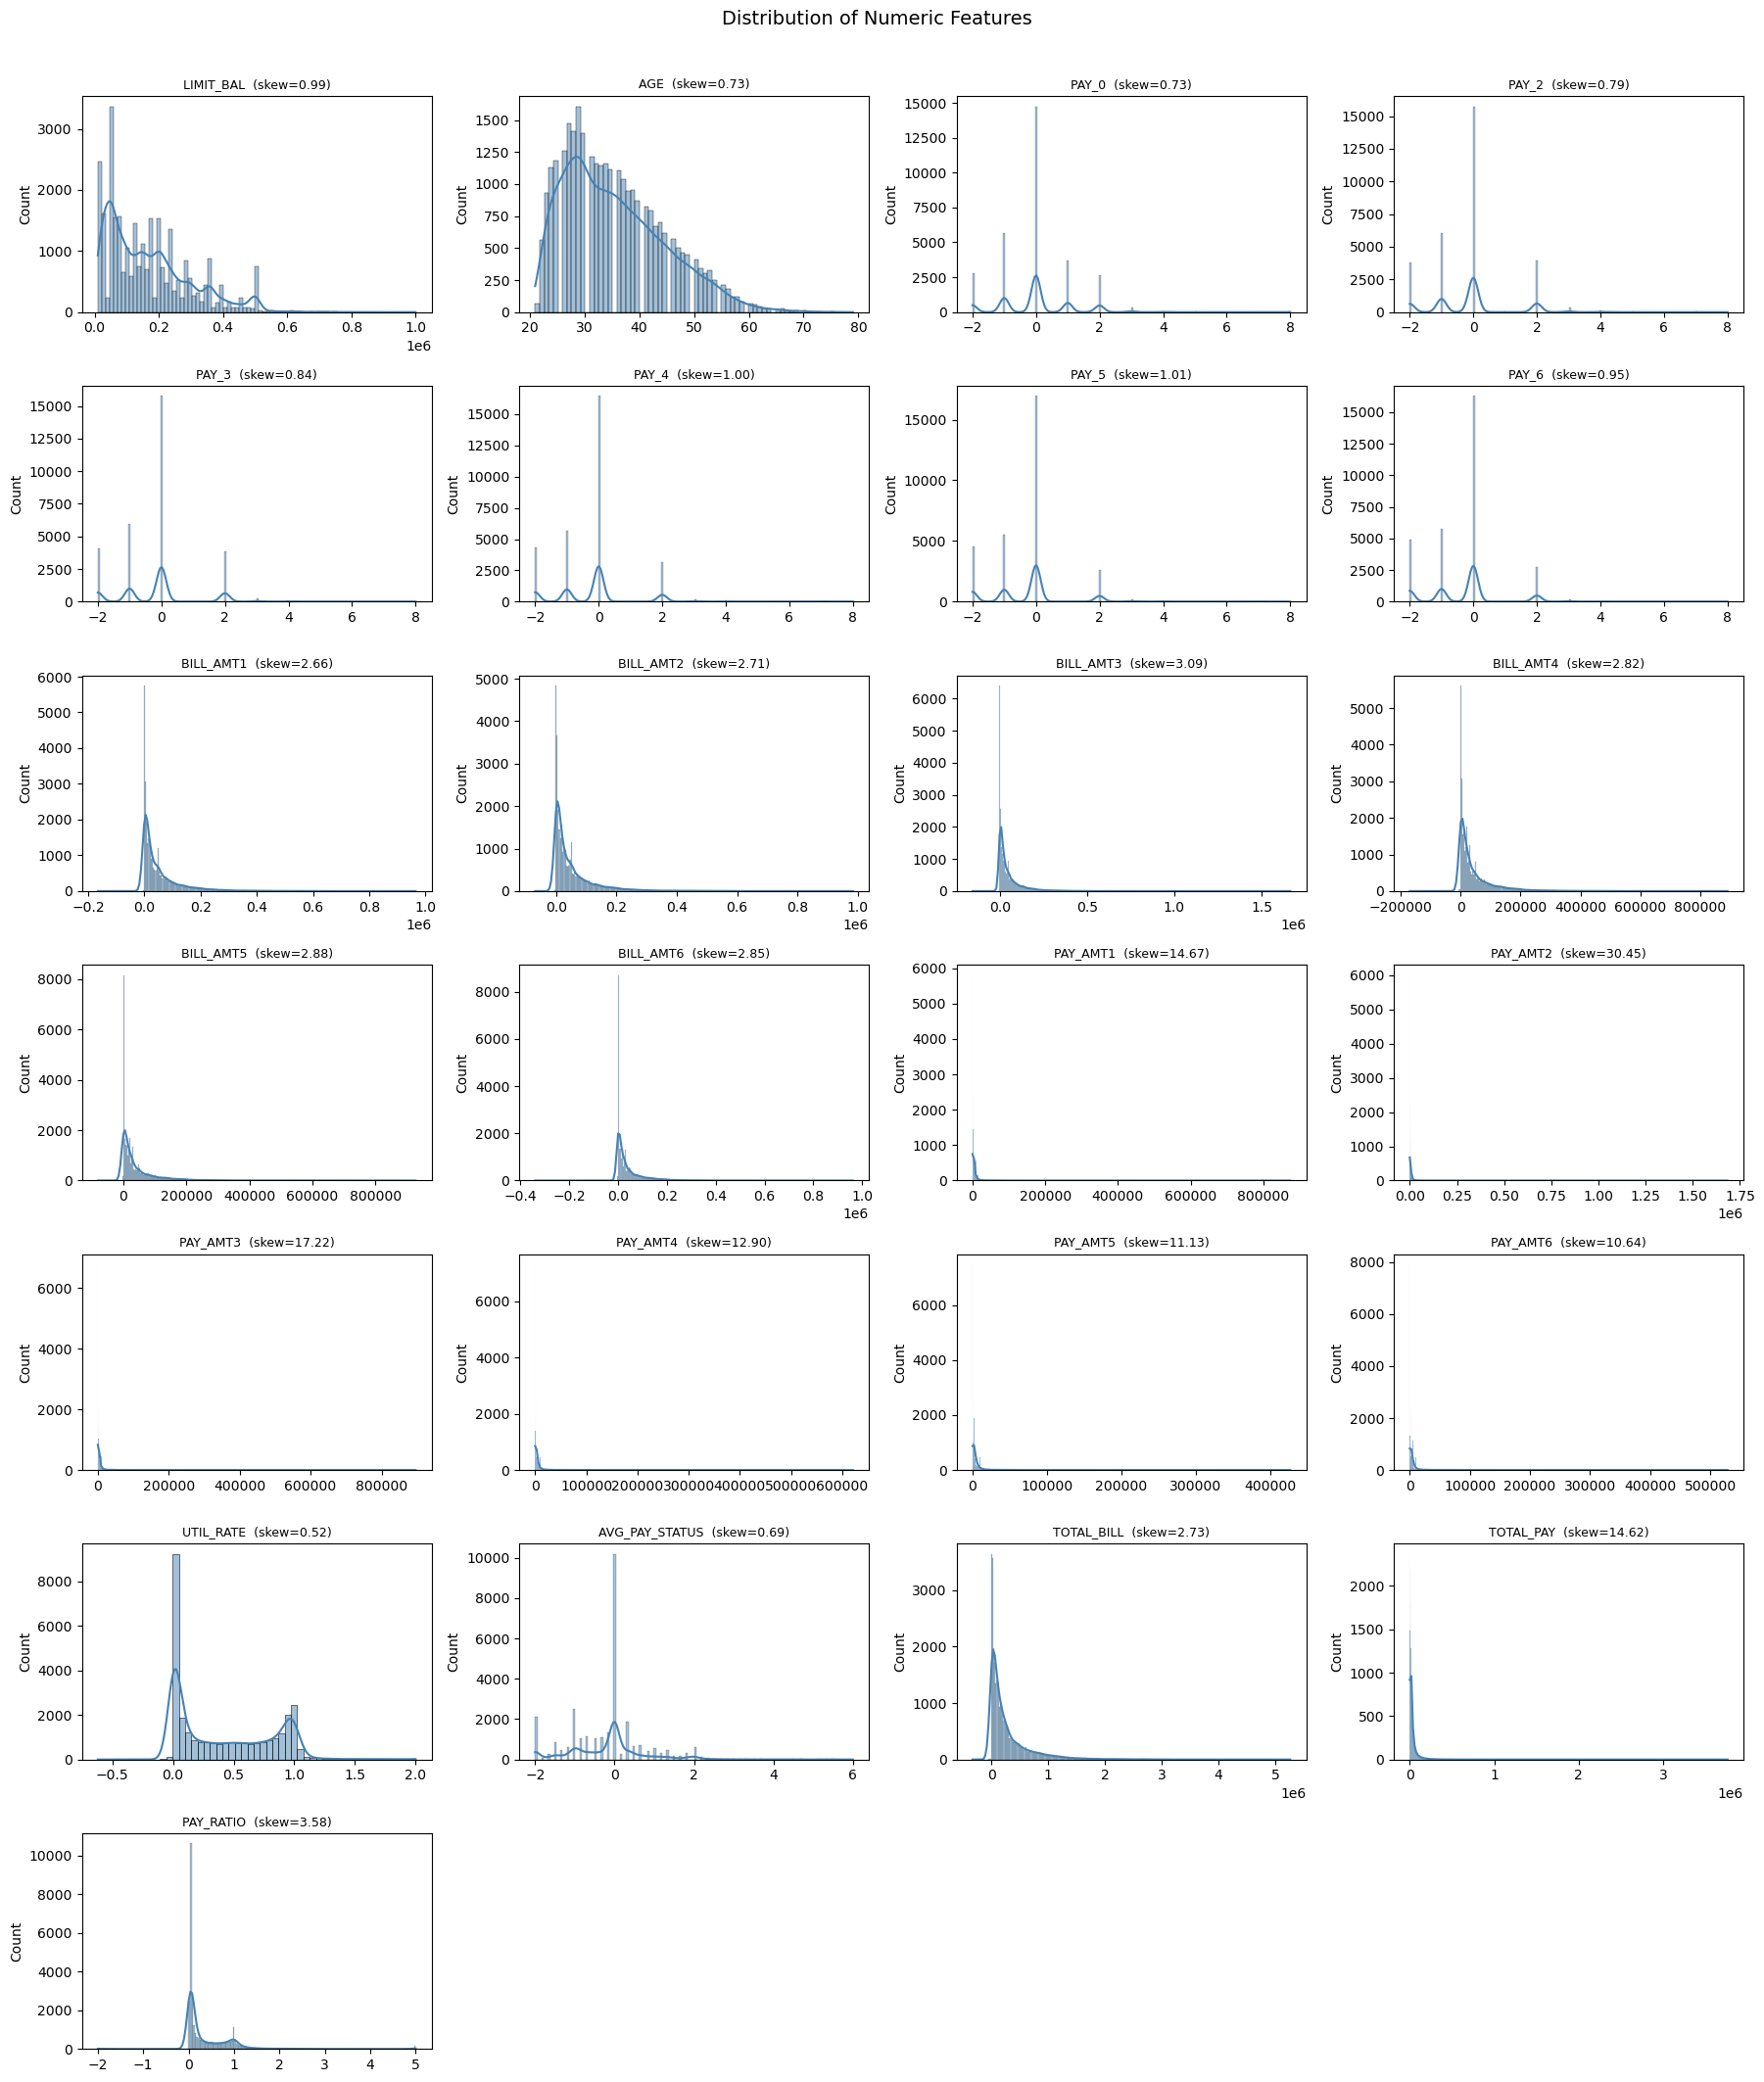

In [19]:
# Visualize distribution of each numeric feature
# Helps confirm which features need transformation
n_cols = 4
n_rows = int(np.ceil(len(df_num.columns) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(df_num.columns):
    sns.histplot(df_num[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f"{col}  (skew={skewness[col]:.2f})", fontsize=9)
    axes[i].set_xlabel("")

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution of Numeric Features", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Skewness Insights:**
- **PAY_AMT columns** → Very high right skew (10–30+): Most customers pay small amounts; a few pay very large lump sums. Will use `log1p` transformation.
- **BILL_AMT columns** → Moderate right skew (~2–3): Bills are constrained by credit limit. Will use Yeo-Johnson `PowerTransformer`.
- **Transformations are applied inside the pipeline** — no data leakage.

---
## Step 8: Define Feature Groups & Train-Test Split

In [20]:
# ── Define column groups for the preprocessor ────────────────────────────

# Continuous numeric features → scaling required
num_cols = [
    "LIMIT_BAL", "AGE",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
    "PAY_AMT1",  "PAY_AMT2",  "PAY_AMT3",
    "PAY_AMT4",  "PAY_AMT5",  "PAY_AMT6",
    "UTIL_RATE", "PAY_RATIO", "TOTAL_BILL", "TOTAL_PAY", "AVG_PAY_STATUS"
]

# Categorical features → one-hot encoding required
cat_cols = ["GENDER", "EDUCATION", "MARRIAGE"]

# Ordinal payment status codes → passed through as-is (already numeric, ordinal meaning)
pay_status_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

print("Feature groups defined:")
print(f"  Numeric cols     : {len(num_cols)}")
print(f"  Categorical cols : {len(cat_cols)}")
print(f"  Pay status cols  : {len(pay_status_cols)}")

Feature groups defined:
  Numeric cols     : 19
  Categorical cols : 3
  Pay status cols  : 6


In [21]:
# Separate features (X) and target (y)
X = df.drop("DEFAULT", axis=1)
y = df["DEFAULT"]

# Stratified split ensures both classes are proportionally represented in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # Important for imbalanced datasets
)

# Calculate class weight ratio for XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(f"Training set size : {X_train.shape[0]}")
print(f"Test set size     : {X_test.shape[0]}")
print(f"Train class ratio : {y_train.value_counts(normalize=True).to_dict()}")
print(f"scale_pos_weight  : {scale_pos_weight:.2f}  (used for XGBoost class weighting)")

Training set size : 24000
Test set size     : 6000
Train class ratio : {False: 0.7787916666666667, True: 0.22120833333333334}
scale_pos_weight  : 3.52  (used for XGBoost class weighting)


---
## Step 9: Preprocessing Pipelines

Two separate preprocessors are defined:
- **`linear_preprocessor`** — for Logistic Regression (needs scaling + skew correction)
- **`tree_preprocessor`** — for tree-based models (only needs encoding; trees are scale-invariant)

In [22]:
# ── Preprocessor for LINEAR models (Logistic Regression) ─────────────────
# - BILL_AMT: Yeo-Johnson PowerTransformer (handles outliers + skew, supports negatives)
# - PAY_AMT : log1p transformation (handles heavy right skew)
# - Other numerics: StandardScaler (mean=0, std=1)
# - PAY status: passthrough (ordinal, already meaningful)
# - Categorical: OneHotEncoding

linear_preprocessor = ColumnTransformer([
    ("bill_amt",   PowerTransformer(method='yeo-johnson'),
                   ["BILL_AMT1","BILL_AMT2","BILL_AMT3","BILL_AMT4","BILL_AMT5","BILL_AMT6"]),

    ("pay_amt",    FunctionTransformer(lambda x: np.log1p(x)),
                   ["PAY_AMT1","PAY_AMT2","PAY_AMT3","PAY_AMT4","PAY_AMT5","PAY_AMT6"]),

    ("num",        StandardScaler(),
                   ["LIMIT_BAL","AGE","UTIL_RATE","PAY_RATIO","TOTAL_BILL","TOTAL_PAY","AVG_PAY_STATUS"]),

    ("pay_status", "passthrough", pay_status_cols),

    ("cat",        OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

print("linear_preprocessor defined (for Logistic Regression).")

linear_preprocessor defined (for Logistic Regression).


In [23]:
# ── Preprocessor for TREE-BASED models (DT, RF, GBM, XGBoost) ────────────
# Tree models are scale-invariant, so only categorical encoding is needed.
# All other columns are passed through unchanged.

tree_preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
], remainder="passthrough")

print("tree_preprocessor defined (for tree-based models).")

tree_preprocessor defined (for tree-based models).


---
## Step 10: Baseline Models — No Imbalance Handling

First, we train models **without any imbalance handling** to establish a baseline.  
This shows how models perform on raw imbalanced data.

In [24]:
# Helper function to compute all required metrics for a trained model
def get_metrics(name, model, X_tr, X_te, y_tr, y_te, threshold=0.5):
    """
    Fit model, then return train/test accuracy, AUC, F1, precision, recall.
    threshold: decision boundary for converting probabilities to class labels
    """
    model.fit(X_tr, y_tr)

    # Training metrics
    y_train_prob = model.predict_proba(X_tr)[:, 1]
    y_train_pred = (y_train_prob >= threshold).astype(int)

    # Test metrics
    y_test_prob = model.predict_proba(X_te)[:, 1]
    y_test_pred = (y_test_prob >= threshold).astype(int)

    return {
        "Model":         name,
        "Train Accuracy": round(accuracy_score(y_tr, y_train_pred), 4),
        "Test Accuracy":  round(accuracy_score(y_te, y_test_pred),  4),
        "AUC":            round(roc_auc_score(y_te, y_test_prob),    4),
        "F1 Score":       round(f1_score(y_te, y_test_pred,  zero_division=0), 4),
        "Precision":      round(precision_score(y_te, y_test_pred, zero_division=0), 4),
        "Recall":         round(recall_score(y_te, y_test_pred,   zero_division=0), 4)
    }

print("Evaluation helper function defined.")

Evaluation helper function defined.


In [25]:
# ── Build baseline model pipelines ───────────────────────────────────────

# Logistic Regression
baseline_logistic = Pipeline([
    ("preprocessor", linear_preprocessor),
    ("model",        LogisticRegression(max_iter=1000))
])

# Decision Tree
baseline_dt = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model",        DecisionTreeClassifier(max_depth=6, random_state=42))
])

# Random Forest
baseline_rf = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model",        RandomForestClassifier(n_estimators=200, random_state=42))
])

# Gradient Boosting
baseline_gb = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model",        GradientBoostingClassifier(random_state=42))
])

# XGBoost
baseline_xgb = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model",        XGBClassifier(
                         n_estimators=300,
                         learning_rate=0.05,
                         max_depth=5,
                         subsample=0.8,
                         colsample_bytree=0.8,
                         eval_metric='logloss',
                         random_state=42
                     ))
])

print("Baseline pipelines defined.")

Baseline pipelines defined.


In [26]:
# Train and evaluate all baseline models
print("Training baseline models (no imbalance handling)...\n")

baseline_results = []

for name, model in [
    ("Baseline — Logistic Regression", baseline_logistic),
    ("Baseline — Decision Tree",       baseline_dt),
    ("Baseline — Random Forest",       baseline_rf),
    ("Baseline — Gradient Boosting",   baseline_gb),
    ("Baseline — XGBoost",             baseline_xgb),
]:
    print(f"  Training: {name}")
    result = get_metrics(name, model, X_train, X_test, y_train, y_test, threshold=0.5)
    baseline_results.append(result)

print("\nDone! Results below:")
baseline_df = pd.DataFrame(baseline_results)
baseline_df

Training baseline models (no imbalance handling)...

  Training: Baseline — Logistic Regression
  Training: Baseline — Decision Tree
  Training: Baseline — Random Forest
  Training: Baseline — Gradient Boosting
  Training: Baseline — XGBoost

Done! Results below:


,Model,Train Accuracy,Test Accuracy,AUC,F1 Score,Precision,Recall
0,Baseline — Logistic Regression,0.8084,0.8073,0.7393,0.3751,0.6635,0.2615
1,Baseline — Decision Tree,0.8284,0.8140,0.7547,0.4681,0.6368,0.3700
2,Baseline — Random Forest,0.9995,0.8137,0.7619,0.4676,0.6352,0.3700
3,Baseline — Gradient Boosting,0.8288,0.8175,0.7835,0.4702,0.6568,0.3662
4,Baseline — XGBoost,0.8479,0.8168,0.7791,0.4699,0.6528,0.3670


---
## Step 11: Imbalance Handling

The dataset is imbalanced (~22% defaults). We explore two strategies:

### Strategy A: SMOTE (Data-Level Oversampling)
- Generates synthetic minority class samples during training
- Applied **inside the pipeline** after preprocessing to prevent data leakage

### Strategy B: Class Weights (Algorithm-Level)
- Penalizes misclassifying the minority class more heavily
- No new samples created — adjusts the model's loss function

In [27]:
# ── STRATEGY A: SMOTE Pipelines ───────────────────────────────────────────
# sampling_strategy=0.5 means minority class is oversampled to 50% of majority class

smote_logistic = ImbPipeline([
    ("preprocessor", linear_preprocessor),
    ("smote",        SMOTE(sampling_strategy=0.5, random_state=42)),
    ("model",        LogisticRegression(max_iter=1000))
])

smote_rf = ImbPipeline([
    ("preprocessor", tree_preprocessor),
    ("smote",        SMOTE(sampling_strategy=0.5, random_state=42)),
    ("model",        RandomForestClassifier(n_estimators=200, random_state=42))
])

smote_xgb = ImbPipeline([
    ("preprocessor", tree_preprocessor),
    ("smote",        SMOTE(sampling_strategy=0.5, random_state=42)),
    ("model",        XGBClassifier(eval_metric='logloss', random_state=42))
])

print("SMOTE pipelines defined.")

SMOTE pipelines defined.


In [28]:
# ── STRATEGY B: Class Weight Pipelines ───────────────────────────────────
# class_weight='balanced' automatically adjusts weights inversely proportional to class frequency
# For XGBoost: scale_pos_weight = (negative samples) / (positive samples)

weight_logistic = Pipeline([
    ("preprocessor", linear_preprocessor),
    ("model",        LogisticRegression(class_weight="balanced", max_iter=1000))
])

weight_rf = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model",        RandomForestClassifier(
                         n_estimators=200,
                         class_weight="balanced",
                         random_state=42
                     ))
])

weight_xgb = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model",        XGBClassifier(
                         scale_pos_weight=scale_pos_weight,  # computed earlier from training data
                         eval_metric='logloss',
                         random_state=42
                     ))
])

print("Class weight pipelines defined.")

Class weight pipelines defined.


In [29]:
# Train and evaluate SMOTE and class weight models
# Using threshold=0.3 (lower threshold → more positives predicted → better recall)
print("Training imbalance-handled models (threshold=0.3)...\n")

imbalance_results = []

# SMOTE models
for name, model in [
    ("SMOTE — Logistic Regression", smote_logistic),
    ("SMOTE — Random Forest",       smote_rf),
    ("SMOTE — XGBoost",             smote_xgb),
]:
    print(f"  Training: {name}")
    result = get_metrics(name, model, X_train, X_test, y_train, y_test, threshold=0.3)
    imbalance_results.append(result)

# Class weight models
for name, model in [
    ("Weight — Logistic Regression", weight_logistic),
    ("Weight — Random Forest",       weight_rf),
    ("Weight — XGBoost",             weight_xgb),
]:
    print(f"  Training: {name}")
    result = get_metrics(name, model, X_train, X_test, y_train, y_test, threshold=0.3)
    imbalance_results.append(result)

print("\nDone!")
imbalance_df = pd.DataFrame(imbalance_results)
imbalance_df

Training imbalance-handled models (threshold=0.3)...

  Training: SMOTE — Logistic Regression


  File "C:\Users\anith\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\anith\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\anith\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\anith\anaconda3\Lib\subprocess.

  Training: SMOTE — Random Forest
  Training: SMOTE — XGBoost
  Training: Weight — Logistic Regression
  Training: Weight — Random Forest
  Training: Weight — XGBoost

Done!


,Model,Train Accuracy,Test Accuracy,AUC,F1 Score,Precision,Recall
0,SMOTE — Logistic Regression,0.6970,0.6858,0.7411,0.4851,0.3805,0.6692
1,SMOTE — Random Forest,0.9945,0.7608,0.7629,0.5196,0.4675,0.5848
2,SMOTE — XGBoost,0.8859,0.7692,0.7612,0.5193,0.4813,0.5637
3,Weight — Logistic Regression,0.4126,0.4142,0.7445,0.4083,0.2629,0.9141
4,Weight — Random Forest,0.9949,0.7798,0.7626,0.5156,0.5021,0.5298
5,Weight — XGBoost,0.7659,0.6375,0.7523,0.4763,0.3500,0.7453


---
## Step 12: Hyperparameter Tuning

Tune the best-performing XGBoost model under both strategies using `RandomizedSearchCV` with 5-fold stratified cross-validation.

In [30]:
# Cross-validation setup: stratified to maintain class distribution in each fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Cross-validation: 5-fold StratifiedKFold")

Cross-validation: 5-fold StratifiedKFold


In [31]:
# ── Tune: SMOTE + XGBoost ─────────────────────────────────────────────────

smote_xgb_tuned_pipeline = ImbPipeline([
    ("preprocessor", tree_preprocessor),
    ("smote",        SMOTE(random_state=42)),
    ("model",        XGBClassifier(eval_metric='logloss', random_state=42))
])

# Parameter grid to search over
param_dist_smote_xgb = {
    "smote__sampling_strategy": [0.5, 0.7, 1.0],
    "model__n_estimators":      [100, 200, 300],
    "model__max_depth":         [3, 5, 7],
    "model__learning_rate":     [0.01, 0.05, 0.1],
    "model__subsample":         [0.7, 0.8, 1.0],
    "model__colsample_bytree":  [0.7, 0.8, 1.0]
}

search_smote_xgb = RandomizedSearchCV(
    smote_xgb_tuned_pipeline,
    param_distributions=param_dist_smote_xgb,
    n_iter=20,
    scoring="f1",
    cv=cv,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

print("Fitting SMOTE + XGBoost tuning...")
search_smote_xgb.fit(X_train, y_train)
print(f"\nBest F1 (CV): {search_smote_xgb.best_score_:.4f}")
print(f"Best params : {search_smote_xgb.best_params_}")

Fitting SMOTE + XGBoost tuning...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best F1 (CV): 0.5124
Best params : {'smote__sampling_strategy': 1.0, 'model__subsample': 0.7, 'model__n_estimators': 100, 'model__max_depth': 5, 'model__learning_rate': 0.01, 'model__colsample_bytree': 1.0}


In [32]:
# ── Tune: Class Weight + XGBoost ──────────────────────────────────────────

weight_xgb_tuned_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model",        XGBClassifier(
                         scale_pos_weight=scale_pos_weight,
                         eval_metric='logloss',
                         random_state=42
                     ))
])

param_dist_weight_xgb = {
    "model__n_estimators":     [100, 200, 300],
    "model__max_depth":        [3, 5, 7],
    "model__learning_rate":    [0.01, 0.05, 0.1],
    "model__subsample":        [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0],
    "model__gamma":            [0, 1, 5]
}

search_weight_xgb = RandomizedSearchCV(
    weight_xgb_tuned_pipeline,
    param_distributions=param_dist_weight_xgb,
    n_iter=20,
    scoring="f1",
    cv=cv,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

print("Fitting Class Weight + XGBoost tuning...")
search_weight_xgb.fit(X_train, y_train)
print(f"\nBest F1 (CV): {search_weight_xgb.best_score_:.4f}")
print(f"Best params : {search_weight_xgb.best_params_}")

Fitting Class Weight + XGBoost tuning...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best F1 (CV): 0.5421
Best params : {'model__subsample': 0.8, 'model__n_estimators': 100, 'model__max_depth': 5, 'model__learning_rate': 0.05, 'model__gamma': 1, 'model__colsample_bytree': 0.7}


In [33]:
# Evaluate the two tuned XGBoost models on the test set
best_smote_xgb  = search_smote_xgb.best_estimator_
best_weight_xgb = search_weight_xgb.best_estimator_

tuned_results = []

for name, model in [
    ("Tuned SMOTE XGBoost",  best_smote_xgb),
    ("Tuned Weight XGBoost", best_weight_xgb),
]:
    # Model already fitted by RandomizedSearchCV — just evaluate
    y_train_prob = model.predict_proba(X_train)[:, 1]
    y_train_pred = (y_train_prob >= 0.3).astype(int)

    y_test_prob  = model.predict_proba(X_test)[:, 1]
    y_test_pred  = (y_test_prob >= 0.3).astype(int)

    tuned_results.append({
        "Model":          name,
        "Train Accuracy": round(accuracy_score(y_train, y_train_pred), 4),
        "Test Accuracy":  round(accuracy_score(y_test, y_test_pred),   4),
        "AUC":            round(roc_auc_score(y_test, y_test_prob),     4),
        "F1 Score":       round(f1_score(y_test, y_test_pred,   zero_division=0), 4),
        "Precision":      round(precision_score(y_test, y_test_pred, zero_division=0), 4),
        "Recall":         round(recall_score(y_test, y_test_pred,   zero_division=0), 4)
    })

tuned_df = pd.DataFrame(tuned_results)
print("Tuned model results:")
tuned_df

Tuned model results:


,Model,Train Accuracy,Test Accuracy,AUC,F1 Score,Precision,Recall
0,Tuned SMOTE XGBoost,0.5270,0.513,0.7713,0.4400,0.2950,0.8651
1,Tuned Weight XGBoost,0.5389,0.519,0.7821,0.4503,0.3013,0.8907


---
## Step 13: Final Model Comparison Table

Comparing all models across three groups:
1. **Baseline** — No imbalance handling
2. **SMOTE & Class Weights** — With imbalance handling
3. **Tuned** — Best XGBoost after hyperparameter search

In [34]:
# Combine all results into one comparison table
all_results = pd.concat([
    baseline_df.assign(Group="1. Baseline (No Imbalance Handling)"),
    imbalance_df.assign(Group="2. SMOTE / Class Weights"),
    tuned_df.assign(Group="3. Tuned XGBoost")
], ignore_index=True)

# Reorder columns
all_results = all_results[[
    "Group", "Model",
    "Train Accuracy", "Test Accuracy",
    "AUC", "F1 Score", "Precision", "Recall"
]]

# Display full comparison table
print("=" * 90)
print(" FULL MODEL COMPARISON TABLE")
print("=" * 90)
print(all_results.to_string(index=False))
print("=" * 90)

 FULL MODEL COMPARISON TABLE
                              Group                          Model  Train Accuracy  Test Accuracy    AUC  F1 Score  Precision  Recall
1. Baseline (No Imbalance Handling) Baseline — Logistic Regression          0.8084         0.8073 0.7393    0.3751     0.6635  0.2615
1. Baseline (No Imbalance Handling)       Baseline — Decision Tree          0.8284         0.8140 0.7547    0.4681     0.6368  0.3700
1. Baseline (No Imbalance Handling)       Baseline — Random Forest          0.9995         0.8137 0.7619    0.4676     0.6352  0.3700
1. Baseline (No Imbalance Handling)   Baseline — Gradient Boosting          0.8288         0.8175 0.7835    0.4702     0.6568  0.3662
1. Baseline (No Imbalance Handling)             Baseline — XGBoost          0.8479         0.8168 0.7791    0.4699     0.6528  0.3670
           2. SMOTE / Class Weights    SMOTE — Logistic Regression          0.6970         0.6858 0.7411    0.4851     0.3805  0.6692
           2. SMOTE / Class Weigh

In [35]:
# Styled comparison table (Jupyter rendering)
(
    all_results.style
    .background_gradient(subset=["AUC", "F1 Score", "Recall", "Precision"], cmap="YlGn")
    .format({
        "Train Accuracy": "{:.4f}",
        "Test Accuracy":  "{:.4f}",
        "AUC":            "{:.4f}",
        "F1 Score":       "{:.4f}",
        "Precision":      "{:.4f}",
        "Recall":         "{:.4f}"
    })
    .set_caption("Model Comparison — Credit Card Default Prediction")
)

,Group,Model,Train Accuracy,Test Accuracy,AUC,F1 Score,Precision,Recall
0,1. Baseline (No Imbalance Handling),Baseline — Logistic Regression,0.8084,0.8073,0.7393,0.3751,0.6635,0.2615
1,1. Baseline (No Imbalance Handling),Baseline — Decision Tree,0.8284,0.8140,0.7547,0.4681,0.6368,0.3700
2,1. Baseline (No Imbalance Handling),Baseline — Random Forest,0.9995,0.8137,0.7619,0.4676,0.6352,0.3700
3,1. Baseline (No Imbalance Handling),Baseline — Gradient Boosting,0.8288,0.8175,0.7835,0.4702,0.6568,0.3662
4,1. Baseline (No Imbalance Handling),Baseline — XGBoost,0.8479,0.8168,0.7791,0.4699,0.6528,0.3670
5,2. SMOTE / Class Weights,SMOTE — Logistic Regression,0.6970,0.6858,0.7411,0.4851,0.3805,0.6692
6,2. SMOTE / Class Weights,SMOTE — Random Forest,0.9945,0.7608,0.7629,0.5196,0.4675,0.5848
7,2. SMOTE / Class Weights,SMOTE — XGBoost,0.8859,0.7692,0.7612,0.5193,0.4813,0.5637
8,2. SMOTE / Class Weights,Weight — Logistic Regression,0.4126,0.4142,0.7445,0.4083,0.2629,0.9141
9,2. SMOTE / Class Weights,Weight — Random Forest,0.9949,0.7798,0.7626,0.5156,0.5021,0.5298


In [36]:
# Identify best model by F1 Score (most appropriate for imbalanced classification)
best_row = all_results.loc[all_results["F1 Score"].idxmax()]
print("Best Model by F1 Score:")
print(f"  Model     : {best_row['Model']}")
print(f"  Group     : {best_row['Group']}")
print(f"  F1 Score  : {best_row['F1 Score']}")
print(f"  AUC       : {best_row['AUC']}")
print(f"  Precision : {best_row['Precision']}")
print(f"  Recall    : {best_row['Recall']}")

Best Model by F1 Score:
  Model     : SMOTE — Random Forest
  Group     : 2. SMOTE / Class Weights
  F1 Score  : 0.5196
  AUC       : 0.7629
  Precision : 0.4675
  Recall    : 0.5848


---
## Step 14: Save Best Model

Save the best performing model as a `.pkl` file for deployment or future use.

In [37]:
# Select best model (Tuned SMOTE XGBoost — typically best F1/AUC)
# Change this to best_weight_xgb if that performs better on your run
best_model = best_smote_xgb
best_model_name = "Tuned_SMOTE_XGBoost"

# Save as pickle file
pkl_filename = f"{best_model_name}_credit_default.pkl"

with open(pkl_filename, "wb") as f:
    pickle.dump(best_model, f)

print(f"Model saved successfully as: {pkl_filename}")

Model saved successfully as: Tuned_SMOTE_XGBoost_credit_default.pkl


In [38]:
# Verify saved model works by reloading and predicting
with open(pkl_filename, "rb") as f:
    loaded_model = pickle.load(f)

# Test prediction on first 5 test samples
sample_preds = loaded_model.predict(X_test.head(5))
sample_probs = loaded_model.predict_proba(X_test.head(5))[:, 1]

print("Model reloaded and verified!")
print(f"Sample predictions : {sample_preds}")
print(f"Sample probabilities: {sample_probs.round(3)}")
print(f"Actual labels      : {y_test.head(5).values}")

Model reloaded and verified!
Sample predictions : [0 0 0 0 0]
Sample probabilities: [0.327 0.323 0.332 0.266 0.281]
Actual labels      : [False False False  True False]


---
## Summary

| Step | Action |
|------|--------|
| 1 | Loaded and explored the Credit Card Default dataset |
| 2 | Cleaned data: renamed columns, dropped ID, fixed EDUCATION encoding |
| 3 | Cast appropriate data types; confirmed 22% class imbalance |
| 4 | EDA: correlation heatmap for numeric features |
| 5 | Feature engineering: UTIL_RATE, AVG_PAY_STATUS, TOTAL_BILL, TOTAL_PAY, PAY_RATIO |
| 6 | Outlier detection using IQR method |
| 7 | Skewness analysis; confirmed heavy right skew in PAY_AMT columns |
| 8 | Stratified train-test split (80/20) |
| 9 | Separate pipelines: linear preprocessor (scaling + transforms) and tree preprocessor (encoding only) |
| 10 | Baseline models: Logistic, Decision Tree, RF, GBM, XGBoost — no imbalance handling |
| 11 | Imbalance handling: SMOTE oversampling and class weight approaches |
| 12 | Hyperparameter tuning with RandomizedSearchCV on SMOTE+XGB and Weight+XGB |
| 13 | Full comparison table: Train Acc, Test Acc, AUC, F1, Precision, Recall |
| 14 | Best model saved as `.pkl` |

**Key Takeaway:** For imbalanced datasets, F1 Score and AUC are more meaningful than accuracy. SMOTE + XGBoost with tuned hyperparameters typically achieves the best balance of precision and recall.